In [1]:
!pip install scikit-image

In [2]:
import numpy as np
from aicspylibczi import CziFile
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter 
from skimage.filters import threshold_otsu

In [3]:
pth = Path('img/SEcell7.czi')
czi = CziFile(pth)

In [4]:
img_frames = []
for t in range(0,250):
    frame_t, _ = czi.read_image(Z=0, T=t, C=0, H=0)
    img_frames.append(frame_t[0, 0, 0, 0, :, :])

img_frames = np.array(img_frames)
img_frames.shape

(250, 512, 512)

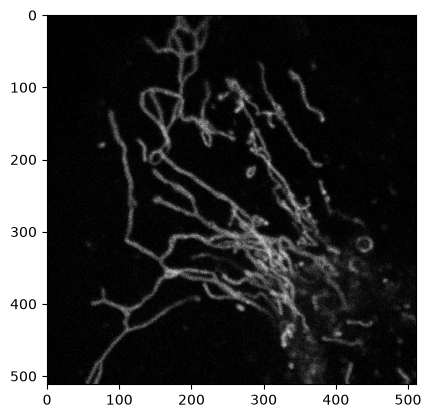

In [5]:
plt.imshow(img_frames[0], cmap="gray")

In [6]:
frame_idx = 131
frame = np.copy(img_frames[frame_idx])

frame = gaussian_filter(frame, sigma=1.5)

threshold = threshold_otsu(frame)

# Apply the threshold mask
otsu_frame = frame > threshold

In [7]:
def plot_patches(original_patches, patch_size, stride, otsu_patches=None):
    x_positions = range(0, frame.shape[0] - patch_size + 1, stride)
    y_positions = range(0, frame.shape[1] - patch_size + 1, stride)

    nrows = len(x_positions)
    ncols = len(y_positions)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 19),
        squeeze=False
    )

    if otsu_patches:
        for idx, (tile, mask) in enumerate(zip(original_patches, otsu_patches)):
            row = idx // ncols
            col = idx % ncols

            axes[row, col].imshow(tile, cmap="gray")
            axes[row, col].contour(
                mask,
                levels=[0.5],
                colors="red",
                linewidths=1
            )
            axes[row, col].axis("off")
            
    else:
        for idx, tile in enumerate(original_patches):
            row = idx // ncols
            col = idx % ncols

            axes[row, col].imshow(tile, cmap="gray")
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

In [8]:
def create_patches(tile_size : int, stride_proportion : float, otsu : bool=False):
    stride = int(tile_size * stride_proportion)

    patches = [
        frame[x:x + tile_size, y:y + tile_size]
        for x in range(0, frame.shape[0] - tile_size + 1, stride)
        for y in range(0, frame.shape[1] - tile_size + 1, stride)
    ]
    
    if otsu:
        otsu_patches = [threshold_otsu(tile) for tile in patches]

        otsu_result_patches = [
            tile > otsu_threshold
            for tile, otsu_threshold in zip(patches, otsu_patches)
        ]

    else:
        otsu_result_patches = None

    plot_patches(original_patches=patches, otsu_patches=otsu_result_patches, patch_size=tile_size, stride=stride)

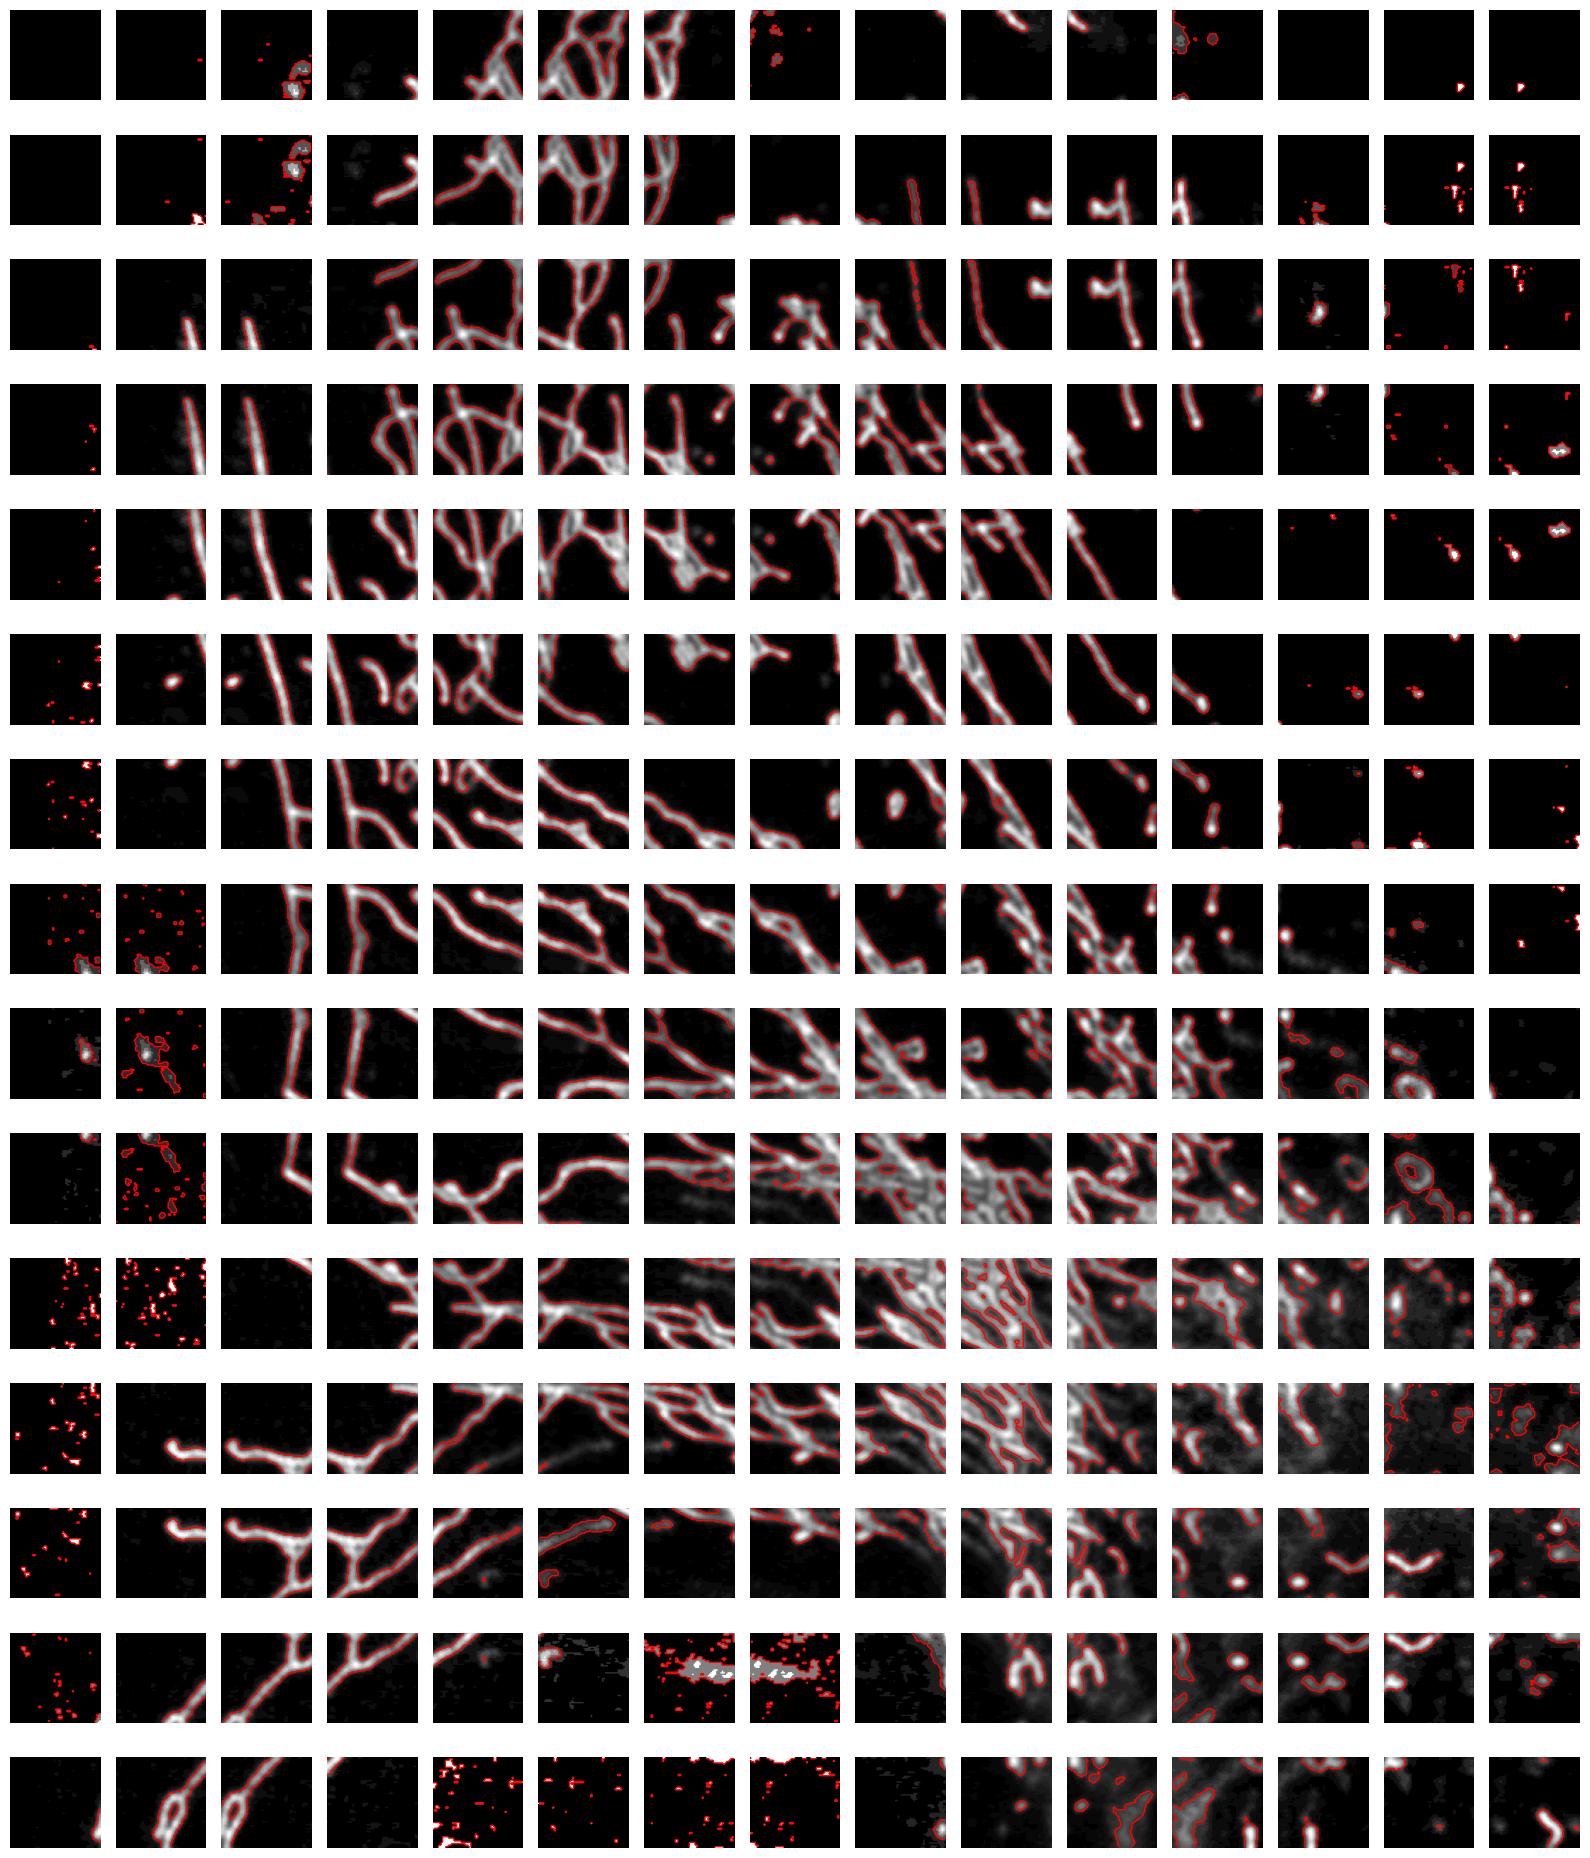

In [9]:
tile_size_1 = 64
stride_proportion_1 = 1/2

create_patches(tile_size=tile_size_1, stride_proportion=stride_proportion_1, otsu=True)

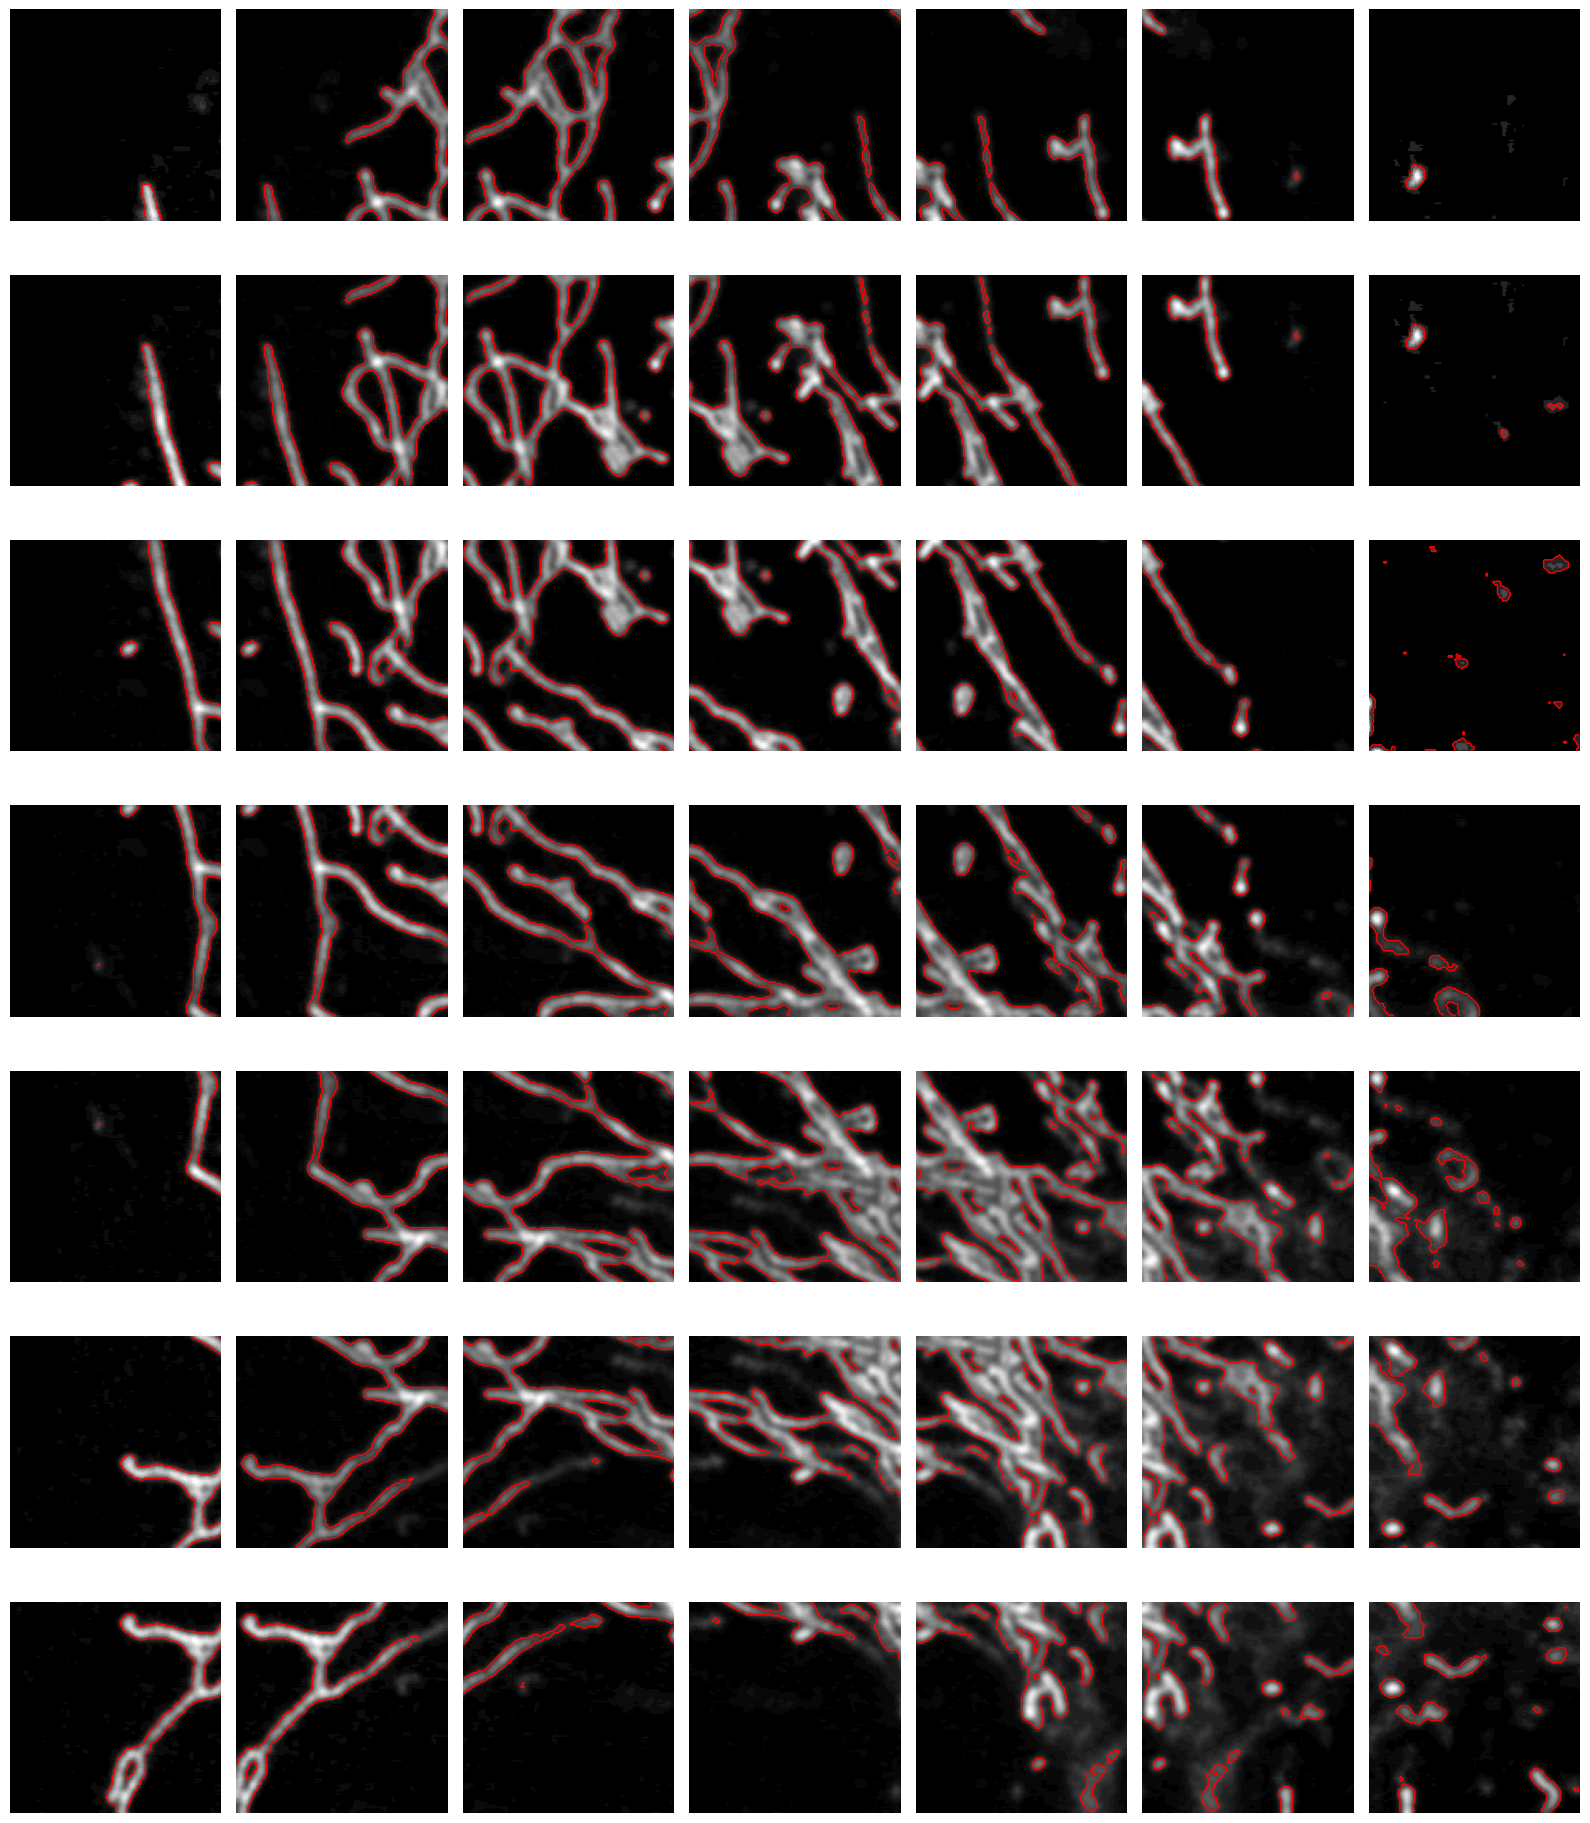

In [10]:
tile_size_2 = 128
stride_proportion_2 = 1/2

create_patches(tile_size=tile_size_2, stride_proportion=stride_proportion_2, otsu=True)

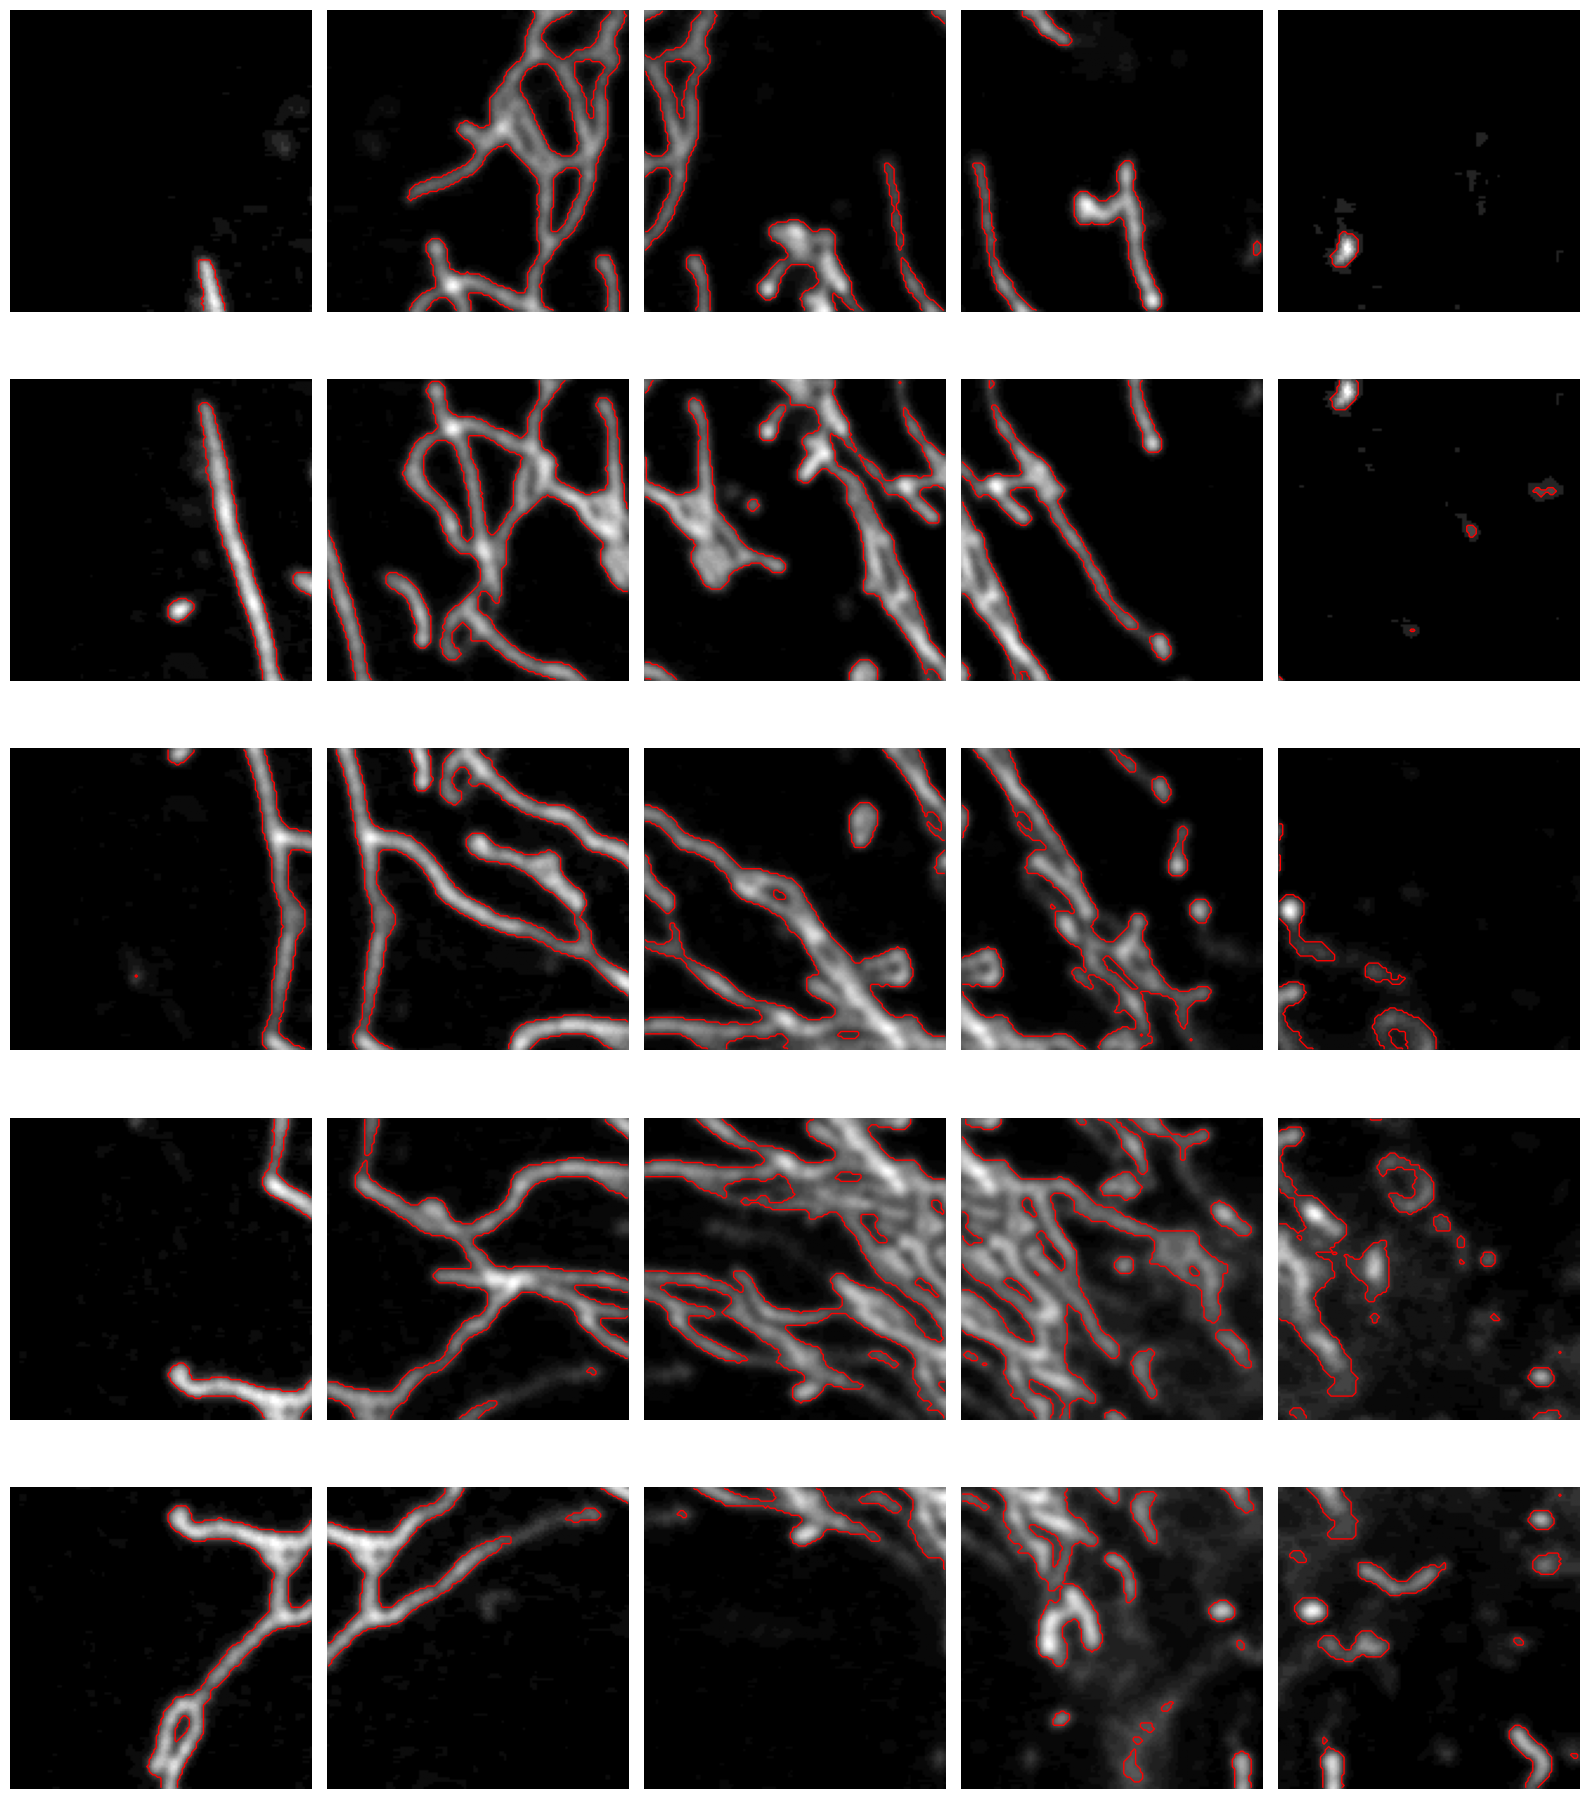

In [11]:
tile_size_3 = 128
stride_proportion_3 = 3/4

create_patches(tile_size=tile_size_3, stride_proportion=stride_proportion_3, otsu=True)

In [26]:
from skimage.filters import gaussian
from skimage.morphology import skeletonize
from skimage.filters import threshold_otsu, threshold_triangle
from skimage.morphology import remove_small_objects

In [13]:
imagen_original = img_frames[0]

/tmp/ipykernel_18020/271694112.py:11: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary_raw, min_size=20)


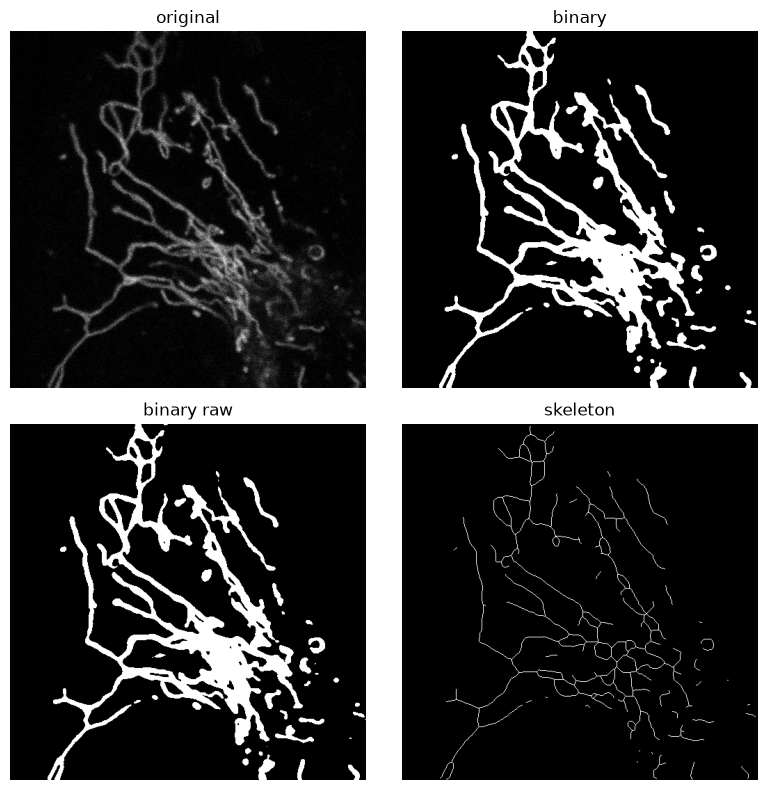

In [37]:
from skimage.morphology import skeletonize, thin

# 1. Suavizado con filtro Gaussiano
img_blurred = gaussian(imagen_original, sigma=1.5)

# 2. Otsu
thresh = threshold_otsu(img_blurred)
binary_raw = img_blurred > thresh

# 3. Eliminando objetos que midan menos de 20 píxeles
binary = remove_small_objects(binary_raw, min_size=20)

skeleton = skeletonize(binary)
thinned = thin(binary)

# 4. Puntos de ramificación abiertos: sólo marcamos un nodo de ramificación
# cuando es una intersección de la skeleton (>= 3 vecinos) y además posee
# al menos un extremo abierto en su vecindario local (grado 1), para excluir
# ramificaciones cerradas en bucles.
skeleton_bool = skeleton.astype(bool)
pad = np.pad(skeleton_bool, 1, mode='constant', constant_values=False)

branch_counts = np.zeros_like(skeleton_bool, dtype=int)
endpoint_counts = np.zeros_like(skeleton_bool, dtype=int)

for dy in range(-1, 2):
    for dx in range(-1, 2):
        if dx == 0 and dy == 0:
            continue
        window = pad[1 + dy:1 + dy + skeleton.shape[0],
                     1 + dx:1 + dx + skeleton.shape[1]].astype(int)
        branch_counts += window
        endpoint_counts += (window == 1).astype(int)

# Conectividad 8-neighbors: un punto de rama se considera abierto si tiene
# >= 3 vecinos activos y al menos un vecino terminal en esa vecindad.
branch_mask = skeleton_bool & (branch_counts >= 3) & (endpoint_counts > 0)
branch_points = np.column_stack(np.where(branch_mask))

fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(imagen_original, cmap=plt.cm.gray)
ax[0].set_title('original')
ax[0].axis('off')

ax[1].imshow(binary, cmap=plt.cm.gray)
ax[1].set_title('binary')
ax[1].axis('off')

ax[2].imshow(binary_raw, cmap=plt.cm.gray)
ax[2].set_title('binary raw')
ax[2].axis('off')

ax[3].imshow(skeleton, cmap=plt.cm.gray)
ax[3].set_title('skeleton')
ax[3].axis('off')

fig.tight_layout()
plt.show()

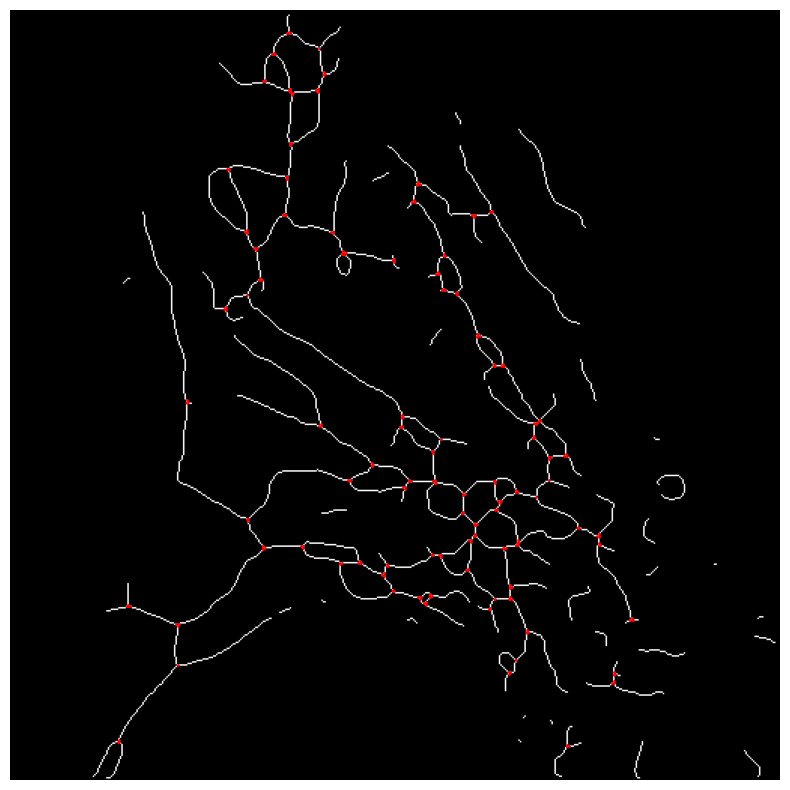

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8), sharex=True, sharey=True)

ax.imshow(skeleton, cmap=plt.cm.gray)
if branch_points.size > 0:
    ax.scatter(branch_points[:, 1], branch_points[:, 0], s=1, color='red', marker='o')
ax.axis('off')

plt.tight_layout()
plt.show()